In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

In [33]:
# DEMOGRAPHIC-ONLY PLOT
# load data
df_wide = pd.read_csv('../data/demographics_only_1/scores.csv')
test_cols = [col for col in df_wide.columns if col.endswith('_test_score')]
id_cols = ['source_run', 'combo_name', 'feature_subset', 'random_state',
           'channels', 'n_features_pre_corr', 'n_features_post_corr']

df_list, test_scores, model_names = list(), list(), list()
for col_name in test_cols:
    df_list.append(df_wide[id_cols])
    test_scores.extend(df_wide[col_name].values)
    model_names.extend(np.repeat(col_name, len(df_wide)))

df = pd.concat(df_list)
df['model_name'] = model_names
df['test_score'] = test_scores

<Axes: xlabel='model_name', ylabel='test_score'>

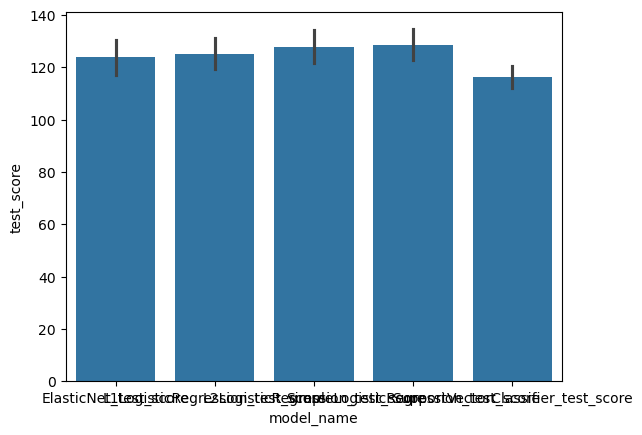

In [35]:
sns.barplot(df, x='model_name', y='test_score')

In [1]:
# DEMOGRAPHIC-ONLY PLOT
# load data
df = pd.read_csv('data/demographics_only_1/scores.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = [col.replace('_test_score', '') for col in test_cols]

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    [models[i] for i in idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 6))
bars = plt.bar(models, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Test Score')
plt.title('Demographic-Only Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(100)
plt.tight_layout()
plt.show()


NameError: name 'pd' is not defined

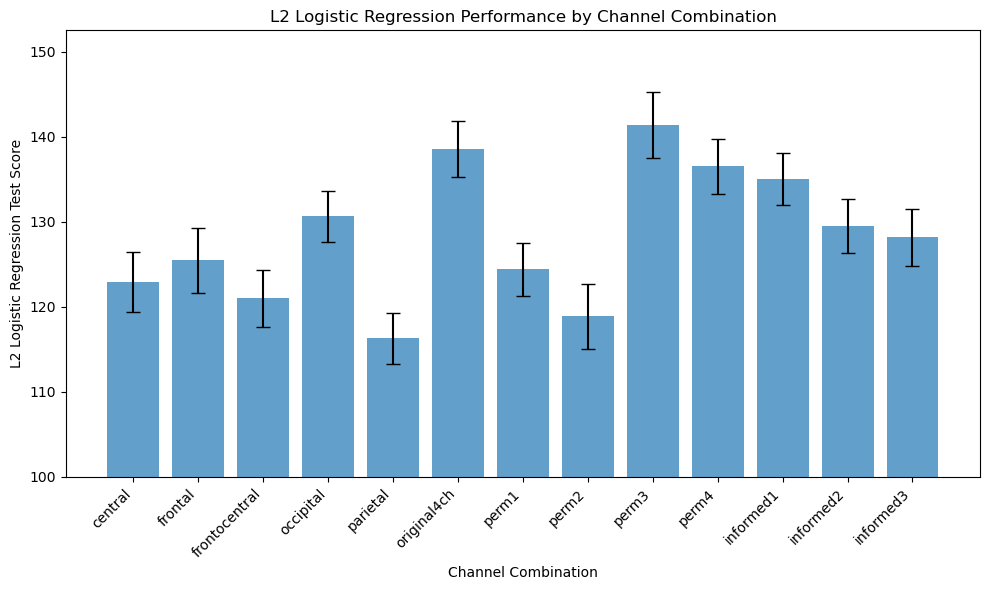

In [11]:
# CHANNEL COMPARISON
# load data
df = pd.read_csv('../data/channel_comparison_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('combo_name')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['central', 'frontal', 'frontocentral', 'occipital', 'parietal', 'original4ch', 'perm1', 'perm2', 'perm3', 'perm4', 'informed1', 'informed2', 'informed3']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Channel Combination')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Channel Combination')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

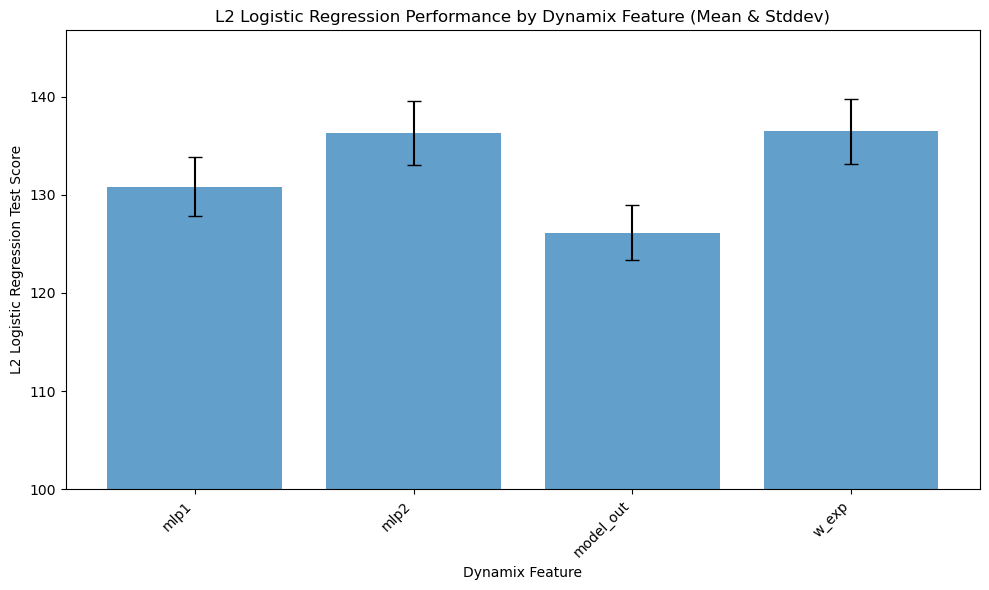

In [4]:
# DYNAMIX FEATURES COMPARISON (MEAN & STD)
# load data
df = pd.read_csv('../data/dynamix_components_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(col):
    match = re.match(r"dynamix_(.*)_std", col)
    if match:
        return match.group(1)
    return col

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Mean & Stddev)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

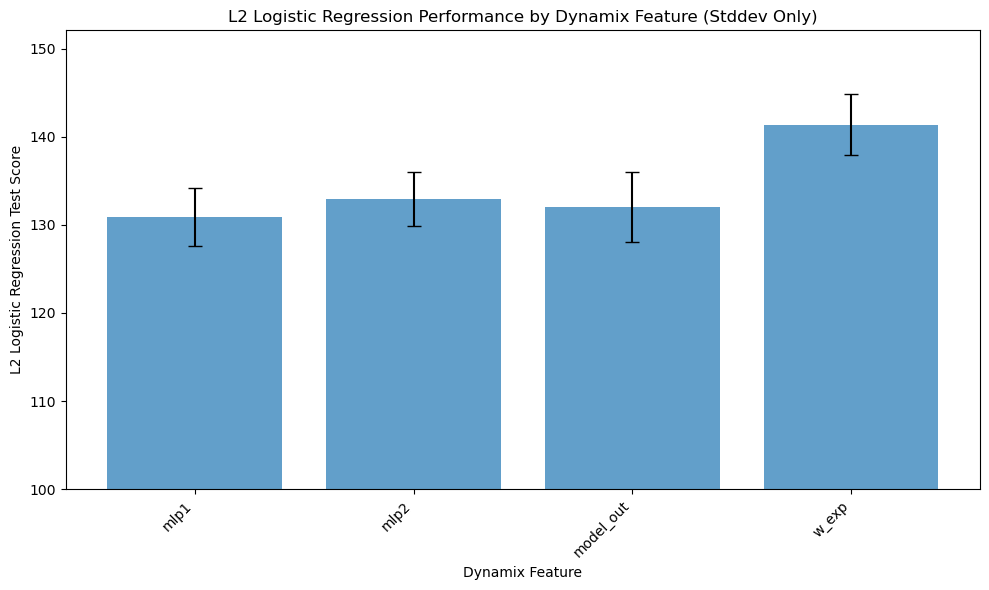

In [5]:
# DYNAMIX FEATURES COMPARISON (STD ONLY)
# load data
df = pd.read_csv('../data/dynamix_components_std_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(col):
    match = re.match(r"dynamix_(.*)_std", col)
    if match:
        return match.group(1)
    return col

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Stddev Only)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

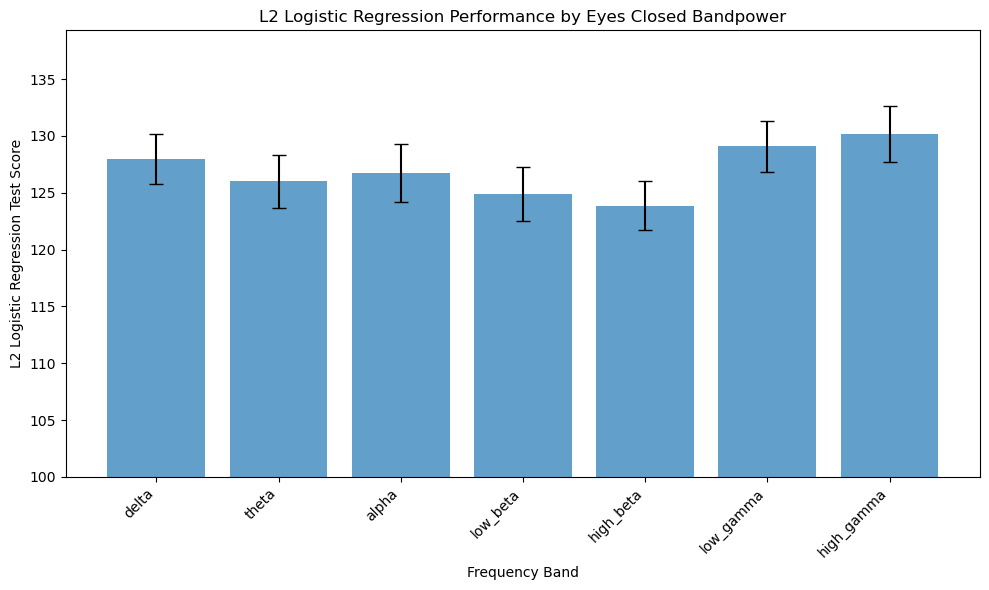

In [6]:
# BANDPOWER SEPARATE
# load data
df = pd.read_csv('../data/bandpower_comparison_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from bandpower_ec_alpha --> alpha
def clean_bp_name(name):
    name = name.replace('bandpower_ec_', '')
    return name

mean_scores.index = mean_scores.index.map(clean_bp_name)
stderr_scores.index = stderr_scores.index.map(clean_bp_name)

# reorder
desired_order = ['delta', 'theta', 'alpha', 'low_beta', 'high_beta', 'low_gamma', 'high_gamma']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Frequency Band')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Eyes Closed Bandpower')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

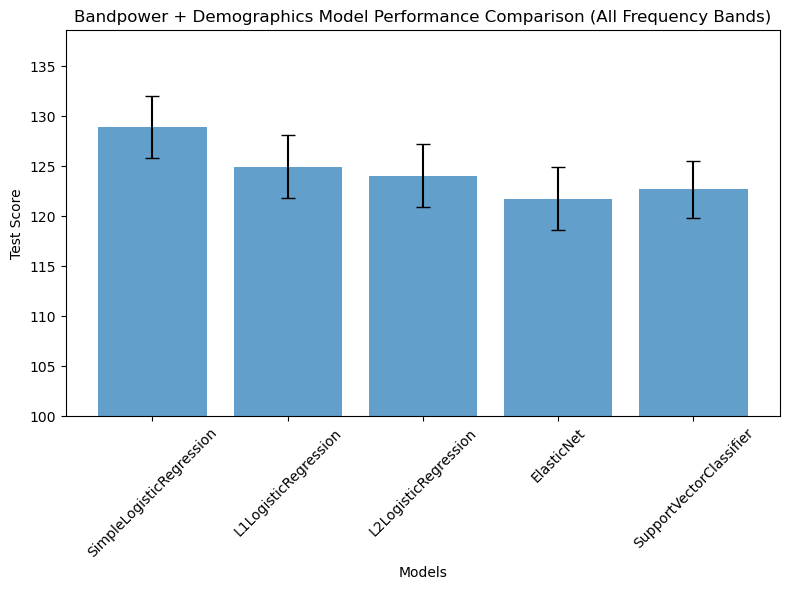

In [7]:
# BANDPOWER ALL (all bandpowers in one feature mat)
# load data
df = pd.read_csv('../data/bandpower_comparison_all/scores.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = [col.replace('_test_score', '') for col in test_cols]

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    [models[i] for i in idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 6))
bars = plt.bar(models, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Test Score')
plt.title('Bandpower + Demographics Model Performance Comparison (All Frequency Bands)')
plt.xticks(rotation=45)
plt.ylim(100)
plt.tight_layout()
plt.show()